Import de dataset y librerias

In [2]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from skforecast.recursive import ForecasterRecursive
import shap
import matplotlib.pyplot as plt
from skforecast.plot import set_dark_theme
from skforecast.model_selection import backtesting_forecaster, TimeSeriesFold
from sklearn.inspection import PartialDependenceDisplay
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from skforecast.model_selection import grid_search_forecaster

dataset = 'Lorca_processed.csv'
                              
data = pd.read_csv(
        dataset,
        sep=";",
        low_memory=False,
)

data = data.sort_index() #Ordenar por fecha

data["datetime"] = pd.to_datetime(data["datetime"], dayfirst=True, errors="coerce") #convertimos time a datatime
data["month"] = data["datetime"].dt.month
data["day"] = data["datetime"].dt.day
data["hour"] = data["datetime"].dt.hour
data["minute"] = data["datetime"].dt.minute

data.drop(columns=["datetime"], inplace=True) #eliminamos la columna Time

exogenas = ['temperature', 'solarRad', 'humedad', 'windSpeed', 'rain', 'pressure', 'pressure_sensor','month', 'day', 'hour', 'minute']


Dividimos en train y test

In [3]:
train_size = int(len(data) * 0.8)

data_train = data.iloc[:train_size]   
data_test  = data.iloc[train_size:]   

Obtenemos los parámetros óptimos

In [4]:
'''parametros = {
    'learning_rate': [0.01, 0.1],
    'max_depth': [5, 9],
    'n_estimators': [200, 900],
    'subsample': [0.6, 0.8, 1.0]
}

forecaster = ForecasterRecursive(
    estimator = XGBRegressor(), 
    lags = 7
)

cv = TimeSeriesFold(
    initial_train_size = int(len(data_train) * 0.05),
    steps = 366,
    gap = 0
)

grid_search = grid_search_forecaster(
    forecaster = forecaster,
    y = data_train['Power_gen'],
    exog = data_train[exogenas],
    param_grid = parametros,
    cv=cv,
    metric = 'mean_absolute_error',
    return_best = True,
    verbose = False
)'''

"parametros = {\n    'learning_rate': [0.01, 0.1],\n    'max_depth': [5, 9],\n    'n_estimators': [200, 900],\n    'subsample': [0.6, 0.8, 1.0]\n}\n\nforecaster = ForecasterRecursive(\n    estimator = XGBRegressor(), \n    lags = 7\n)\n\ncv = TimeSeriesFold(\n    initial_train_size = int(len(data_train) * 0.05),\n    steps = 366,\n    gap = 0\n)\n\ngrid_search = grid_search_forecaster(\n    forecaster = forecaster,\n    y = data_train['Power_gen'],\n    exog = data_train[exogenas],\n    param_grid = parametros,\n    cv=cv,\n    metric = 'mean_absolute_error',\n    return_best = True,\n    verbose = False\n)"

El primer paso es crear el forecaster.

In [5]:
forecaster = ForecasterRecursive(
    estimator = XGBRegressor(learning_rate = 0.01, max_depth = 9, n_estimators = 900, subsample = 0.6),
    lags = 3
)

Entrenamos el forecaster

In [6]:
forecaster.fit(y=data_train['Power_gen'], exog=data_train[exogenas])

Obtenemos las variables mas importantes en el forecaster

In [7]:
importantes = forecaster.get_feature_importances()
print(importantes)

            feature  importance
4          solarRad    0.716734
0             lag_1    0.055814
10            month    0.051885
12             hour    0.040792
1             lag_2    0.026825
2             lag_3    0.019669
5           humedad    0.017711
13           minute    0.015591
3       temperature    0.015553
9   pressure_sensor    0.011465
11              day    0.011131
6         windSpeed    0.009428
8          pressure    0.007402
7              rain    0.000000


Usamos SHAP para crear los datos de entrenamiento

In [8]:
x_train, y_train = forecaster.create_train_X_y(
    y=data_train['Power_gen'],
    exog=data_train[exogenas]
)

print(x_train.head()) 
print(y_train.head(3)) 

    lag_1   lag_2   lag_3  temperature  solarRad  humedad  windSpeed  rain  \
3   0.000  11.512   0.000      12.7778     473.0     46.0    24.1402   0.0   
4   8.651   0.000  11.512      14.4444     594.0     41.0    24.1402   0.0   
5  11.375   8.651   0.000      15.1111     701.0     39.0    17.7028   0.0   
6  13.378  11.375   8.651      16.0000     726.0     34.0    17.7028   0.0   
7  13.874  13.378  11.375      15.7778     332.0     34.0    14.4841   0.0   

   pressure  pressure_sensor  month  day  hour  minute  
3    28.580       395.484262    3.0  8.0  10.0    20.0  
4    28.585       394.392969    3.0  8.0  11.0    20.0  
5    28.572       394.329954    3.0  8.0  12.0    24.0  
6    28.557       457.276472    3.0  8.0  13.0    23.0  
7    28.517       392.994877    3.0  8.0  14.0    27.0  
3     8.651
4    11.375
5    13.378
Name: y, dtype: float64


Explainer del SHAP

In [9]:
explainer = shap.Explainer(forecaster.estimator)

#50% de los datos de entrenamiento
rng = np.random.default_rng(42)
sample_indices = rng.choice(x_train.index, size=int(len(x_train) * 0.5), replace=False)
x_train_sample = x_train.loc[sample_indices,:]
shap_values = explainer.shap_values(x_train_sample)

Grafica resumen de SHAP

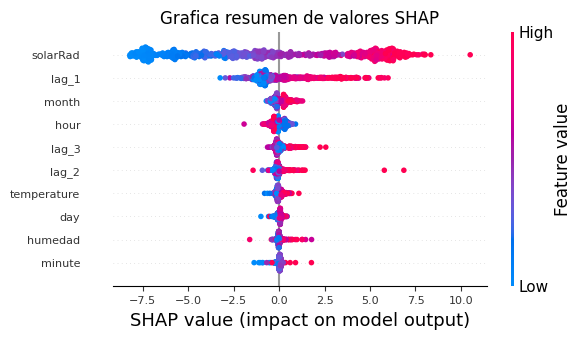

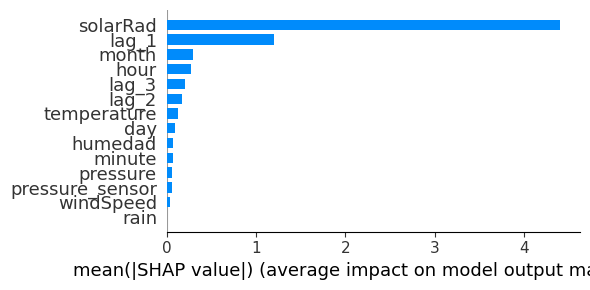

In [10]:
shap.initjs()
shap.summary_plot(shap_values, x_train_sample, max_display=10, show=False)
fig, ax = plt.gcf(), plt.gca()
ax.set_title('Grafica resumen de valores SHAP')
ax.tick_params(labelsize=8)
fig.set_size_inches(6,3)
plt.show()


plt.figure()
shap.summary_plot(shap_values, x_train, plot_type="bar", plot_size=(6, 3))
plt.show()

Grafica de dependencia

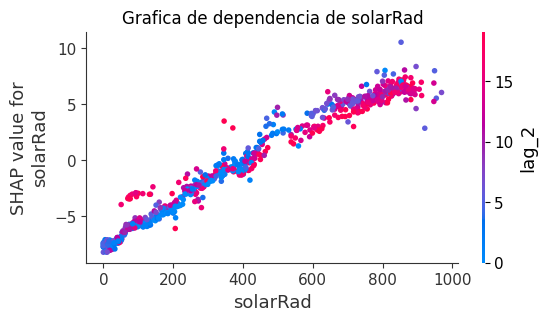

In [11]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.set_title('Grafica de dependencia de solarRad')

shap.dependence_plot("solarRad", shap_values, x_train_sample, ax=ax)
plt.show()

Ahora veremos las explicaciones de SHAP para predicciones de las proximas 366 muestras (data_test)

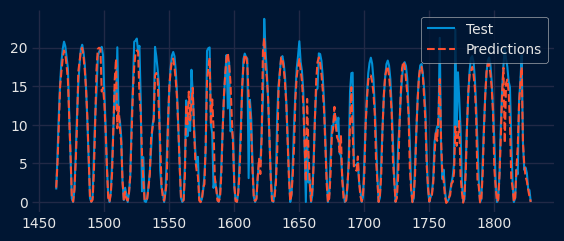

In [12]:
pred = forecaster.predict(steps=366, exog=data_test[exogenas])
set_dark_theme()
fig, ax = plt.subplots(figsize=(6, 2.5))
data_test['Power_gen'].plot(ax=ax, label='Test')
pred.plot(ax=ax, label='Predictions', linestyle='--')
ax.set_xlabel(None)
ax.legend()
plt.show()

Matriz de entrada para la prediccion de las proximas 366 muestras.

In [13]:
x_predict = forecaster.create_predict_X(
    steps=366,
    exog=data_test[exogenas]
)

Valores de SHAP para el backtesting_forecaster

In [14]:
cv = TimeSeriesFold(steps= 24, initial_train_size = len(data_train))
_, predictions = backtesting_forecaster(
                        forecaster        = forecaster,
                        y                 = data['Power_gen'],
                        exog              = data[exogenas],
                        cv                = cv,
                        metric            = 'mean_absolute_error',
                        return_predictors = True,
                )

predictions.head(3)

100%|██████████| 16/16 [00:05<00:00,  2.93it/s]


,fold,pred,lag_1,lag_2,lag_3,temperature,solarRad,humedad,windSpeed,rain,pressure,pressure_sensor,month,day,hour,minute
1463,0,1.853827,0.000000,0.629000,2.632,22.3333,97.0,76.0,6.43738,0.0,28.747,248.304713,8.0,22.0,8.0,23.0
1464,0,5.051413,1.853827,0.000000,0.629,23.7222,223.0,78.0,4.82803,0.0,28.765,247.849818,8.0,22.0,9.0,23.0
1465,0,10.125710,5.051413,1.853827,0.000,25.5556,420.0,68.0,8.04672,0.0,28.768,245.952249,8.0,22.0,10.0,23.0


Graficas de dependencia parcial.

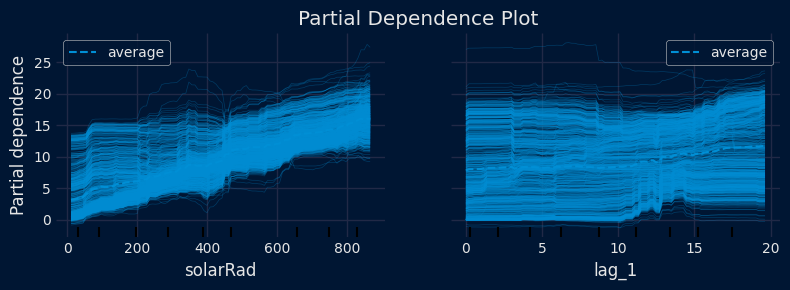

In [15]:
fig, ax = plt.subplots(figsize=(8, 3))
pd.plots = PartialDependenceDisplay.from_estimator(
    estimator = forecaster.estimator,
    X         = x_train,
    features  = ["solarRad", "lag_1"],
    kind      = 'both',
    ax        = ax,
)
ax.set_title("Partial Dependence Plot")
fig.tight_layout()
plt.show()

Metricas de la prediccion

In [16]:
y_test = data_test['Power_gen'].iloc[:len(pred)]

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Coeficiente de determinación (R^2): {r2:.4f}")

Mean Absolute Error (MAE): 1.2605
Mean Squared Error (MSE): 4.7810
Root Mean Squared Error (RMSE): 2.1866
Coeficiente de determinación (R^2): 0.9011


Grafica comparativa realidad vs prediccion

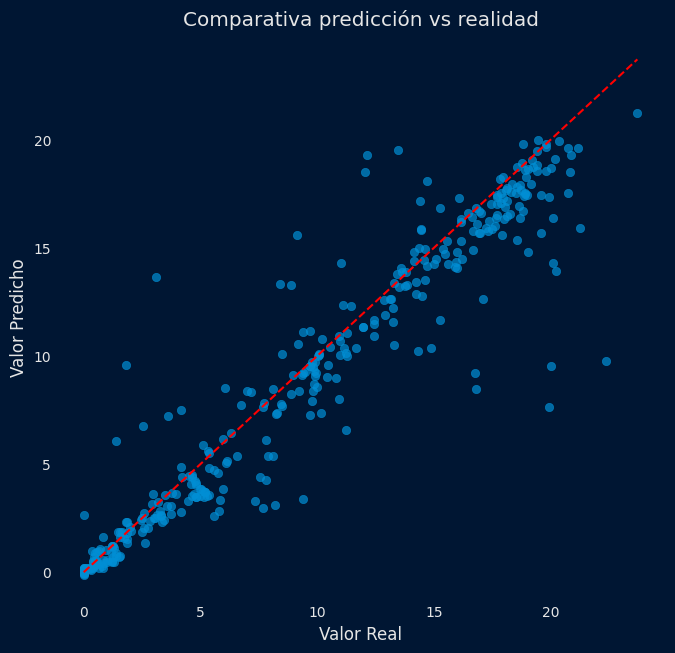

In [17]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  #linea de igualdad
plt.xlabel('Valor Real')
plt.ylabel('Valor Predicho')
plt.title('Comparativa predicción vs realidad')
plt.grid()
plt.show()